# Model Training

In [4]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 929.6 kB/s eta 0:00:09
   -- ------------------------------------- 0.5/8.3 MB 929.6 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.3 MB 958.5 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.3 MB 948.7 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.3 MB 948.7 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.3 MB 894.7 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.3 MB 892.3 kB/s eta 0:00:08
   -------- ------------------------------- 1.8/8.3 MB 898.8 kB/s eta 0:00:08
   -------- ------------------------------- 1.8/8.3 MB 898.8 kB/s eta 0:00:08
   ---------- ----------------------------- 2.1/8.3 MB 917.5 kB/s eta 0:00:07
   ----------

In [6]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.1 MB/s eta 0:01:29
   ---------------------------------------- 0.8/100.2 MB 1.2 MB/s eta 0:01:21
    --------------------------------------- 1.6/100.2 MB 1.9 MB/s eta 0:00:53
    --------------------------------------- 2.1/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 3.1/100.2 MB 2.0 MB/s eta 0:00:48
   - -------------------------------------- 3.7/100.2 MB 2.1 MB/s eta 0:00:46
   - -------------------------------------- 4.2/100.2 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 4.5/100.2 MB 2.1 MB/s eta 0:00:45
   - -------------------------------------- 5.0/100.2 MB 2.1 MB/s eta 0:00:45
   -- -

In [8]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 2.1 MB/s eta 0:00:24
    --------------------------------------- 0.8/48.9 MB 2.0 MB/s eta 0:00:25
   - -------------------------------------- 1.3/48.9 MB 2.0 MB/s eta 0:00:25
   - -------------------------------------- 1.6/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 1.8/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 2.4/48.9 MB 1.9 MB/s eta 0:00:25
   -- ------------------------------------- 2.9/48.9 MB 1.9 MB/s eta 0:00:25
   -- ------------------------------------- 3.1/48.9 MB 1.8 MB/s eta 0:00:25
   -- ------------------------------------- 3.4/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 3.4/48.9 MB 1.8 MB/s eta 0:00:26
   -- ------------------------------------- 3.7/48.9 MB 1.5 MB/s eta 0:00:30
   --- ------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("stud.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X = df.drop(columns=['math_score'],axis = 1)

In [6]:
y=df['math_score']

In [9]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [11]:
print("Categories in gender variables : ",end=" ")
print(df['gender'].unique())
print("Categories in race/ethnicity variables : ",end=" ")
print(df['race_ethnicity'].unique())
print("Categories in parental level of education variables : ",end=" ")
print(df['parental_level_of_education'].unique())
print("Categories in lunch variables : ",end=" ")
print(df['lunch'].unique())
print("Categories in test preparation course variables : ",end=" ")
print(df['test_preparation_course'].unique())

Categories in gender variables :  ['female' 'male']
Categories in race/ethnicity variables :  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental level of education variables :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch variables :  ['standard' 'free/reduced']
Categories in test preparation course variables :  ['none' 'completed']


In [12]:
num_feature = X.select_dtypes(exclude="object").columns
cat_feature = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocesssor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer , cat_feature),
        ("StandardScaler",numeric_transformer,num_feature)
    ]
)

In [14]:
X = preprocesssor.fit_transform(X)

In [17]:
X.shape

(1000, 19)

In [18]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [19]:
X_train.shape , X_test.shape

((800, 19), (200, 19))

In [20]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae , rmse , r2_square

In [22]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoost Regressor" : CatBoostRegressor(verbose = False),
    "Adboost Regressor" : AdaBoostRegressor()

}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse , model_train_r2 = evaluate_model(y_train,y_train_pred)

    model_test_mae , model_test_rmse , model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")
    print("RMSE : ",model_train_rmse)
    print("MAE : ",model_train_mae)
    print("R2 Score : ",model_train_r2)

    print("-------------------------------------")

    print("Model performance for testing set")
    print("RMSE : ",model_test_rmse)
    print("MAE : ",model_test_mae)
    print("R2 Score : ",model_test_r2)
    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")


Linear Regression
Model performance for training set
RMSE :  5.323050852720513
MAE :  4.266711846071957
R2 Score :  0.8743172040139593
-------------------------------------
Model performance for testing set
RMSE :  5.393993869732842
MAE :  4.21476314247485
R2 Score :  0.8804332983749565


Lasso
Model performance for training set
RMSE :  6.593815587795566
MAE :  5.206302661246528
R2 Score :  0.8071462015863456
-------------------------------------
Model performance for testing set
RMSE :  6.519694535667421
MAE :  5.157881810347763
R2 Score :  0.8253197323627852


Ridge
Model performance for training set
RMSE :  5.323324922741654
MAE :  4.264987823725981
R2 Score :  0.8743042615212909
-------------------------------------
Model performance for testing set
RMSE :  5.390387016935638
MAE :  4.21110068801426
R2 Score :  0.8805931485028738


K-Neighbors Regressor
Model performance for training set
RMSE :  5.707884897227694
MAE :  4.51675
R2 Score :  0.8554876322327585
------------------------

In [23]:
pd.DataFrame(list(zip(model_list,r2_list)),columns = ['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoost Regressor,0.851632
5,Random Forest,0.849431
8,Adboost Regressor,0.847288
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.752916


# Linear Regression

In [24]:
lin_model = LinearRegression(fit_intercept = True)
lin_model = lin_model.fit(X_train , y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test , y_pred) * 100
print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 88.04


Text(0, 0.5, 'Predicted')

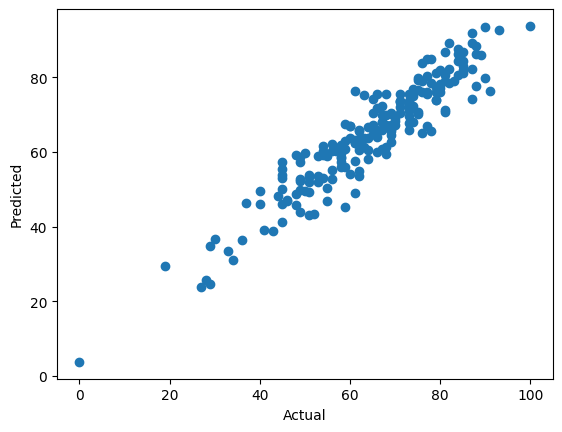

In [25]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

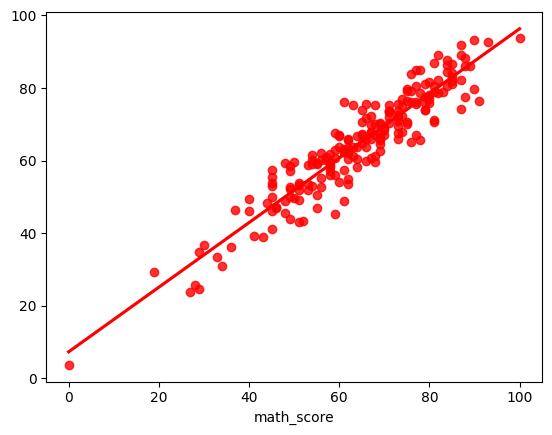

In [26]:
sns.regplot(x=y_test , y=y_pred , ci = None , color = 'red')

In [27]:
pred_df = pd.DataFrame({"Actual Value":y_test , "Predicted Value":y_pred , "Difference":y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
